In [7]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)          
# Remove rows where 'fileID' is in removeFileID
df_info_filtered = df_info[~df_info['fileID'].isin(removeFileID)]

# # Assign the filtered DataFrame back to df_info
df_info = df_info_filtered
factor = -1* 365.25 * 24 * 3600/900

In [2]:


df_best = pd.read_csv('tables/best_ms_method_per_model.csv')

df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
                         
df_dslr2100 = pd.read_csv('./tables/dslc_anom_2100.csv')
df_dslr2200 = pd.read_csv('./tables/dslc_anom_2200.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')

df_tf2100 = pd.read_csv('./tables/thermalforcing_2100.csv')
df_tf2200 = pd.read_csv('./tables/thermalforcing_2200.csv')
df_tf2300 = pd.read_csv('./tables/thermalforcing_2300.csv')

df_iareafl2100 = pd.read_csv('./tables/iareafl_2100.csv')
df_iareafl2200 = pd.read_csv('./tables/iareafl_2200.csv')
df_iareafl2300 = pd.read_csv('./tables/iareafl_2300.csv')

df_iareafl2100_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2100.csv')
df_iareafl2200_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')
df_iareafl2300_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')


dfds = [
    df_m2100 ,
df_m2200 ,
df_m2300 ,
df_bmb2100,
df_bmb2200 ,
df_bmb2300  ,                     
df_tf2100 ,
df_tf2200 ,
df_tf2300 ,
df_iareafl2100, 
df_iareafl2200 ,
df_iareafl2300 ,
df_iareafl2100_change ,
df_iareafl2200_change,
df_iareafl2300_change,


]

for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    
regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',
 'Peninsula',
           'Amundsen',
 'Ross',
 'FilchnerRonne']
regions_keys ={}
regions_keys['AIS'] = ['']
regions_keys['WestAntarctica']=['_region_1']
regions_keys['EastAntarctica']=['_region_2']
regions_keys['Peninsula']=['_region_3']
regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']

Models = df_best.Model.values

In [3]:
df_best

,Unnamed: 0,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_FilchnerRonne,melt_sensetivity_intercept_FilchnerRonne,melt_sensetivity_WestAntarctica,melt_sensetivity_intercept_WestAntarctica,melt_sensetivity_EastAntarctica,melt_sensetivity_intercept_EastAntarctica,melt_sensetivity_Peninsula,melt_sensetivity_intercept_Peninsula
0,0,DC_ISSM,1.959097,df_maxbmb,Quad. Non-local,3.895959,-1.398919,9.183323,-1.582275,3.720531,-1.701558,4.748896,-2.198766,4.348727,-1.900654,4.213586,-1.479211,1.818610,-0.314251
1,1,IGE_ElmerIce,2.965707,df_maxbmb,PICO,2.110396,0.296224,2.831167,9.863159,1.744727,-0.422262,2.038370,-1.195653,1.691065,0.276987,2.872538,-0.184109,4.932470,-1.361450
2,2,ILTS_SICOPOLIS,2.761296,df_maxbmb_2k,Quad. Non-local,5.297964,-1.956686,12.734657,-0.760224,3.574502,-1.451954,5.267966,-2.593836,5.262305,-1.845908,5.079944,-1.745513,3.482976,-1.478106
3,3,LSCE_GRISLI2,3.233607,df_maxbmb_2100,Quad. Non-local,5.947404,-2.765166,12.105475,-1.573739,3.919317,-1.750611,5.475569,-2.567570,5.648605,-2.550484,5.641786,-2.252251,4.520818,-3.269863
4,4,LSCE_GRISLI,3.398583,df_maxbmb_2100,Quad. Non-local,6.106663,-2.900344,12.657794,-2.433293,3.930029,-1.769565,5.561223,-2.607899,5.732383,-2.679052,5.717830,-2.309375,4.130935,-2.908215
5,5,NCAR_CISM1,2.301010,df_maxbmb_2k,Quad. Non-local,4.281649,-1.686388,5.717034,-6.741590,3.152983,-1.302097,4.783804,-2.478397,4.473627,-1.943489,4.243672,-1.596607,2.048020,0.546405
6,6,NCAR_CISM2,2.602965,df_maxbmb_2k,Quad. Local,6.147876,-2.138430,7.597750,-2.689526,4.204205,-1.254059,7.186805,-2.830221,6.507816,-2.319541,6.134695,-1.947057,2.775852,-0.437819
7,7,NORCE_CISM2-MAR364-ERA-t1,4.299751,df_maxbmb_2k,Quad. Non-local Slope,5.163648,-2.406684,9.607826,-7.581897,1.932915,-0.782667,6.097992,-3.955713,5.214456,-2.647558,5.409420,-2.233244,3.058081,-1.190778
8,8,NORCE_CISM3-MAR364-ERA-t1-local,2.437814,df_maxbmb_2k,Quad. Local,3.880806,-1.385036,3.755640,-1.310094,3.018316,-0.916247,4.714712,-2.092414,4.250863,-1.659539,3.721768,-1.169245,2.347345,-0.658852
9,9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,2.167126,df_maxbmb_2k,Quad. Non-local,4.038875,-1.314914,4.557420,-2.332686,3.380904,-0.998023,4.730729,-1.905328,4.431299,-1.599052,3.942529,-1.137309,2.628339,-0.691143


###  let us look at all models but not UCSD ISSM and ILP KIriBU1 because those are the only ones showing shelf growth. or maybe leave them in for now

In [4]:
msk = (Models != 'UCSD_ISSM') &  ( Models != 'ULB_fETISh-KoriBU1')

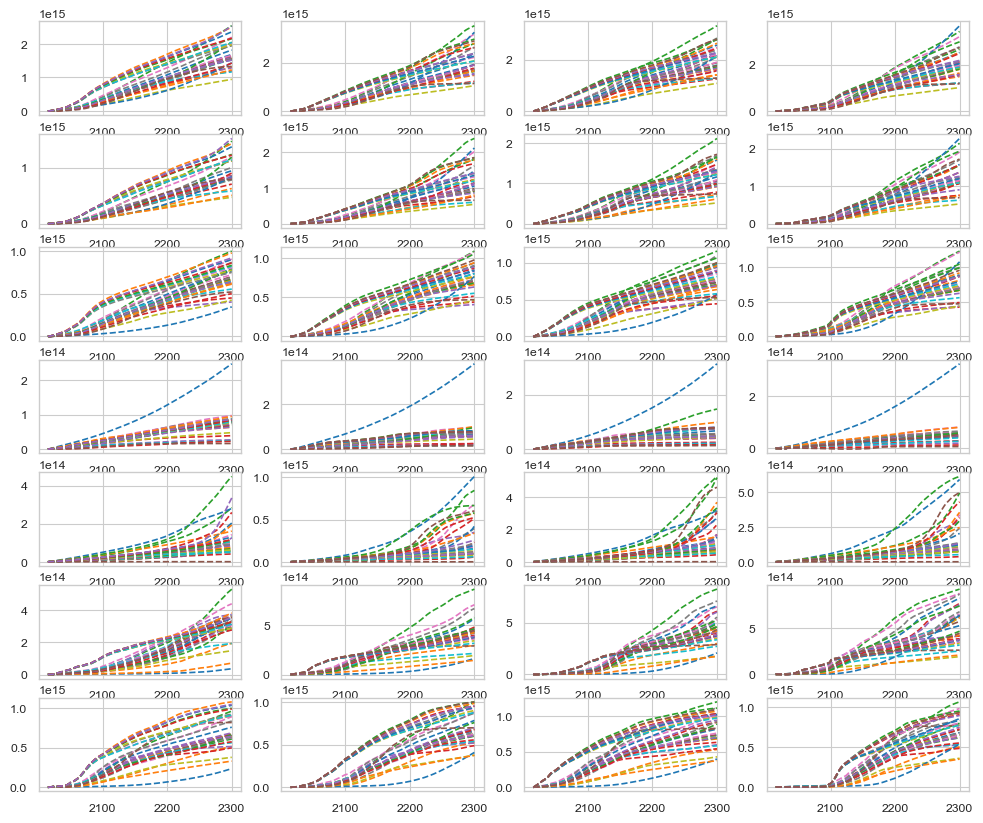

In [8]:
f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for Model in Models:
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           

           
           
       
            ax.plot(d.time.values,y,linestyle = '--' ,label = Model)
                
   


In [8]:
### check different melt param

In [10]:
param_u =np.unique(df_best['parameterization'])
marker_u = ['^','v','*','s','P','p']
cols_u = ['black','steelblue','orange','crimson','green','cyan']
dic_marker = {}
dic_colors_param = {}

for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
    dic_colors_param[key]= cols_u[i]
markers = []
marker_nomodel=[]
colors_param = []
colors_param_nomodel = []

msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best['parameterization']:
    markers.append(dic_marker[key])
    colors_param.append(dic_colors_param[key])
for key in df_best['parameterization'][msk]:
    marker_nomodel.append(dic_marker[key])
    colors_param_nomodel.append(dic_colors_param[key])
    

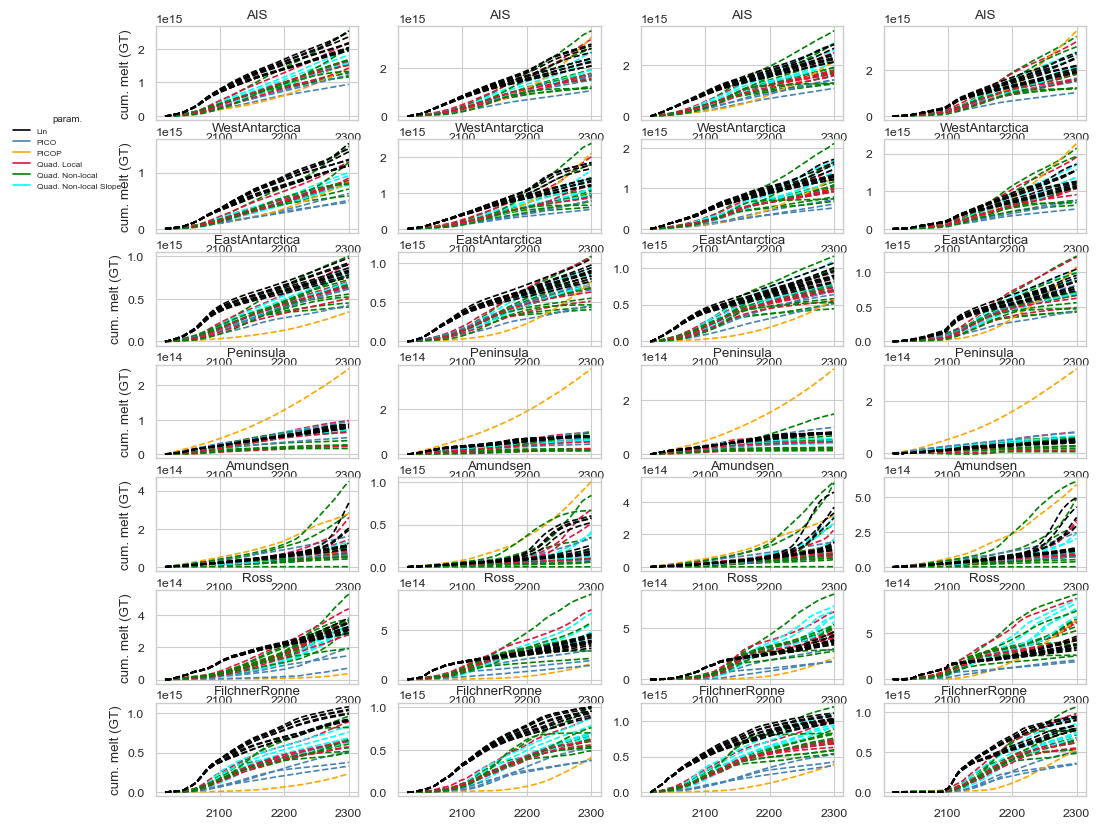

In [12]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_param.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = colors_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('cum. melt (GT)')
   
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


### by ice front treatemnt

In [13]:
df_info[df_info.Experiment == exp]['ice front'].values

array(['MH', 'Fix', 'MH', 'MH', 'MH', 'RO', 'RO', 'RO', 'RO', 'RO', 'RO',
       'RO', 'RO', 'RO', 'RO', 'RO', 'RO', 'RO', 'StR', 'VM', 'Fix',
       'Div', 'Div', 'RO', 'Fix', 'MH', 'StR', 'StR', 'StR', 'StR', 'StR',
       'StR', 'StR', 'StR', 'StR', 'StR'], dtype=object)

In [14]:
icefront_u =np.unique(df_info['ice front'])
cols_u = ['black','steelblue','orange','crimson','green','cyan']

dic_colors_icefront = {}

for i,key in enumerate(icefront_u):

    dic_colors_icefront[key]= cols_u[i]

colors_icefront= []

msk = df_best.Model.values != 'VUW_PISM2_s1'
icefronts_per_model = df_info[df_info.Experiment == exp]['ice front'].values
for key in icefronts_per_model:
   
    colors_icefront.append(dic_colors_icefront[key])


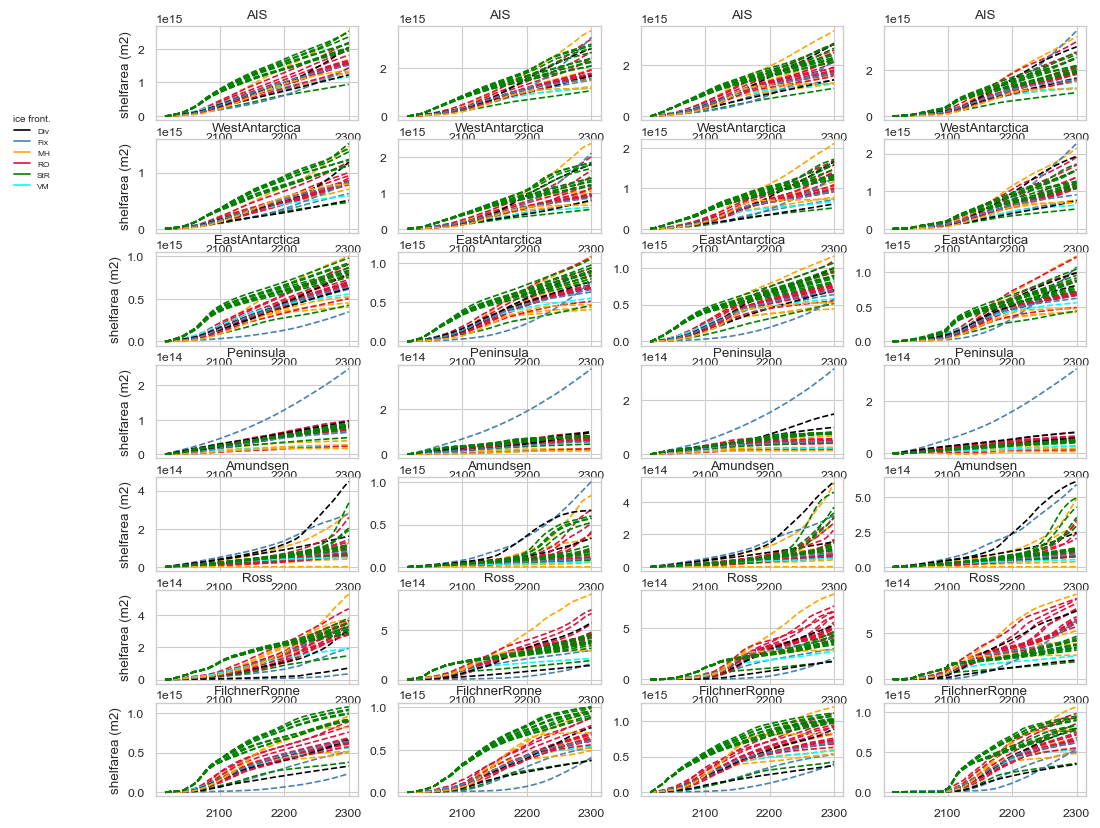

In [17]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_icefront.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = colors_icefront[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   
f.legend(handles=legend_elements, title='ice front.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


### for some there is only one combination of melt param and ice front treate ment so it is hard to tell which  is the influencing part, let us check the combinations

In [18]:

icefront_param_per_model =icefronts_per_model +" "+df_best['parameterization'].values.tolist()

icefront_param_u =np.unique(icefront_param_per_model)
cols_u = ['black','brown','blue','steelblue','orange','fuchsia','crimson','red','olive','green','cyan','pink']

dic_colors_icefrontparam = {}

for i,key in enumerate(icefront_param_u):

    dic_colors_icefrontparam[key]= cols_u[i]

colors_icefront_param= []

# msk = df_best.Model.values != 'VUW_PISM2_s1'
# icefronts_per_model = df_info[df_info.Experiment == exp]['ice front'].values
for key in icefront_param_per_model:
   
    colors_icefront_param.append(dic_colors_icefrontparam[key])


In [36]:
regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',

 'Amundsen',
 'Ross',
 'FilchnerRonne']

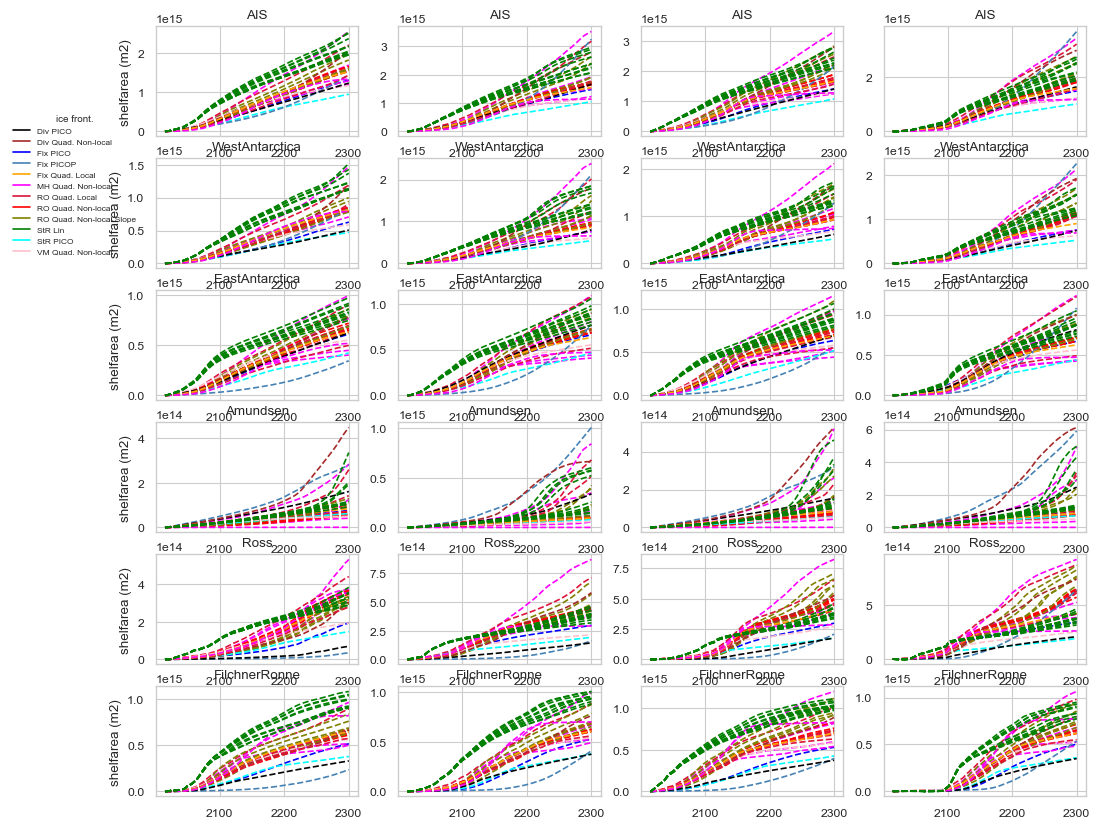

In [37]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_icefrontparam.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = colors_icefront_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   
f.legend(handles=legend_elements, title='ice front.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


### check with ms



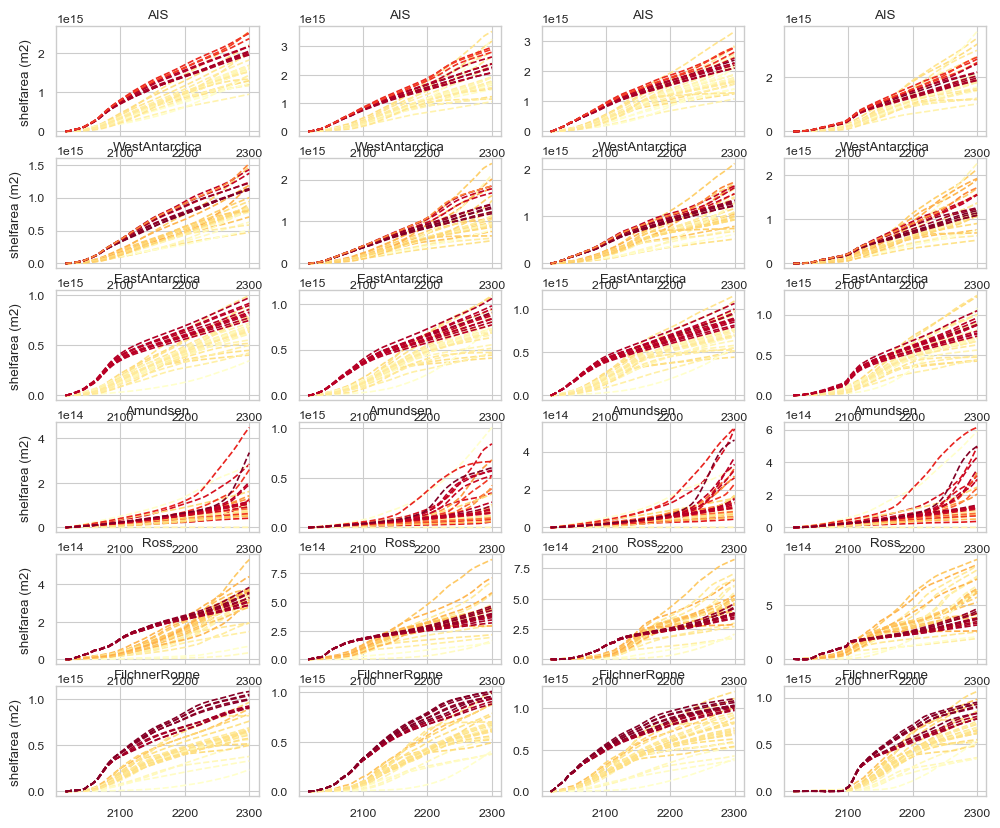

In [71]:
# 1.  MH Quad. Non-local 

Models_1 = df_bmb2100_exp.Model

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('YlOrRd')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   





### NO VUW PISM

In [73]:
df_bmb2100_exp.Model.values

array(['DC_ISSM', 'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
       'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO',
       'VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3',
       'VUW_PISM1_s4', 'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2',
       'VUW_PISM2_s3', 'VUW_PISM2_s4'], dtype=object)

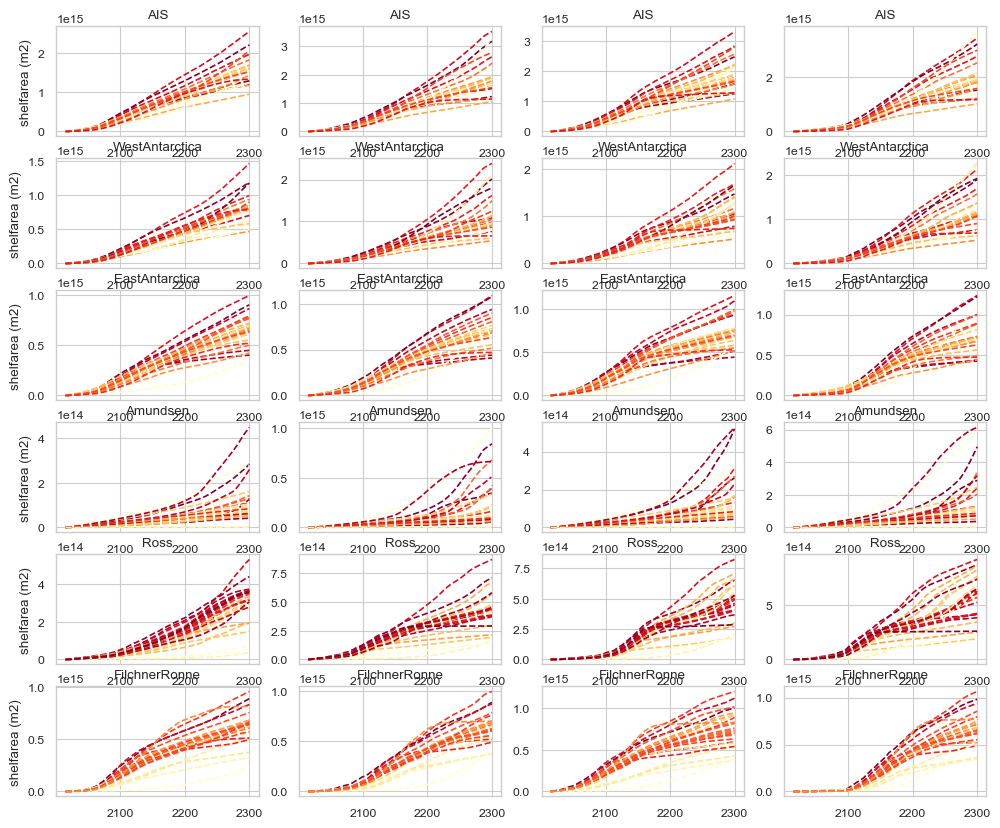

In [151]:
# 1.  MH Quad. Non-local 

Models_1 = ['DC_ISSM', 'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
       'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('YlOrRd')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   




## ms time area changes


In [38]:
df_iareafl2300_change_mean = df_iareafl2300_change[df_iareafl2300_change.Experiment == 'expAE02']

for i,Model in enumerate(df_iareafl2300_change_mean.Model):
    dm =df_iareafl2300_change[df_iareafl2300_change.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
        df_iareafl2300_change_mean.iloc[i,j+3] =dm[varname].values.mean()

In [166]:
df_model

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,region_1,region_2,region_3,FilchnerRonne,Ross,Amundsen,AIS,WestAntarctica,EastAntarctica,Peninsula


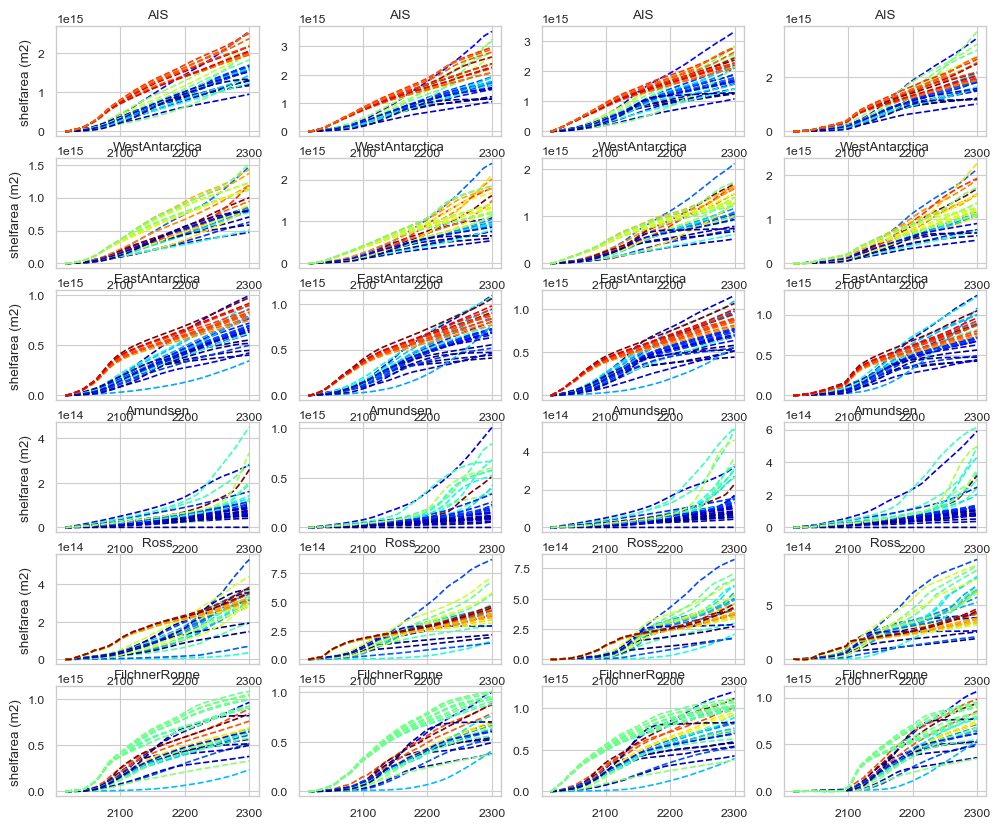

In [172]:
# 1.  MH Quad. Non-local 

Models_1 = ['DC_ISSM', 'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
       'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO','VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2' ,'VUW_PISM1_s3' ,'VUW_PISM1_s4',
  'VUW_PISM2' ,'VUW_PISM2_s1' ,'VUW_PISM2_s2' ,'VUW_PISM2_s3' ,'VUW_PISM2_s4']
# Models_1 = ['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2' ,'VUW_PISM1_s3' ,'VUW_PISM1_s4'
#  'VUW_PISM2' ,'VUW_PISM2_s1' ,'VUW_PISM2_s2' ,'VUW_PISM2_s3' ,
# 'VUW_PISM2_s4']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]*(100 +df_iareafl2300_change_mean[f'{region}'].values[mask_special_model])
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
      
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   




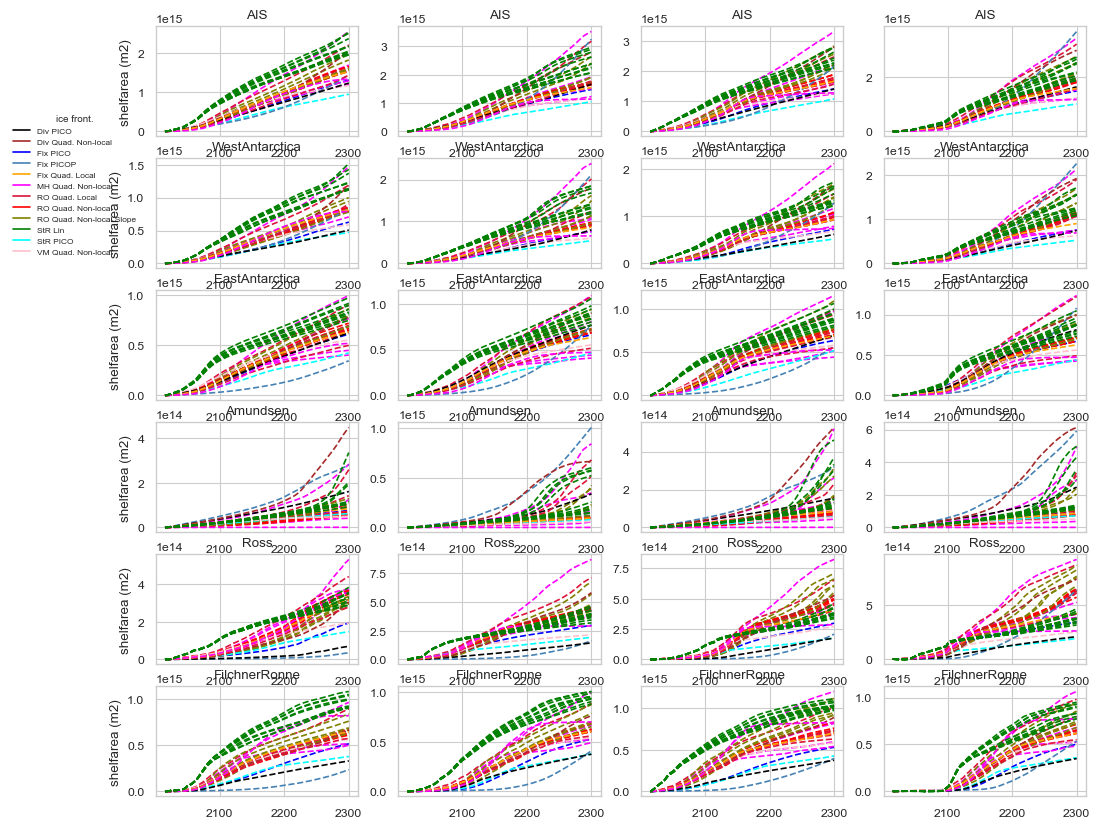

In [171]:

icefront_param_per_model =icefronts_per_model +" "+df_best['parameterization'].values.tolist()

icefront_param_u =np.unique(icefront_param_per_model)
cols_u = ['black','brown','blue','steelblue','orange','fuchsia','crimson','red','olive','green','cyan','pink']

dic_colors_icefrontparam = {}

for i,key in enumerate(icefront_param_u):

    dic_colors_icefrontparam[key]= cols_u[i]

colors_icefront_param= []

# msk = df_best.Model.values != 'VUW_PISM2_s1'
# icefronts_per_model = df_info[df_info.Experiment == exp]['ice front'].values
for key in icefront_param_per_model:
   
    colors_icefront_param.append(dic_colors_icefrontparam[key])


regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',

 'Amundsen',
 'Ross',
 'FilchnerRonne']

#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_icefrontparam.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = colors_icefront_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   
f.legend(handles=legend_elements, title='ice front.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


In [152]:
# Test with pic:

models_group1=[ 'DC_ISSM',  'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
        'UCM_Yelmo',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO',
       ]
models_group2 = ['PIK_PISM','ULB_fETISh-KoriBU1','IGE_ElmerIce'] ## PICO
models_group3=['UCSD_ISSM' ] #PiCOP
models_group4 =['ILTS_SICOPOLIS']
models_group5 =[ ]
models_group6 = ['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3',
       'VUW_PISM1_s4', 'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2',
       'VUW_PISM2_s3', 'VUW_PISM2_s4']


models_groups = [models_group1,models_group2,models_group3,models_group4, models_group5, models_group6]

n = 0

all_model_groups = []
for group in models_groups:
    for m in group:
        all_model_groups.append(m)
    n= n+len(group);
    

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in all_model_groups:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            
            
            
            
            
            
    
            



all_groups =[models_group1,models_group2,models_group3,models_group4,models_group5, models_group6]


cols_u = ['black','blue','cyan','fuchsia','green','orange']

groups_cat = np.zeros_like(Models)-1

for i,Model in enumerate(Models):
    for j, group in enumerate(all_groups):
        for gmodel in group:
           
            if gmodel == Model:
                groups_cat[i]=j
                
groups_cat

array([0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1,
       0, 0, 0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5], dtype=object)

In [153]:
Models[groups_cat==5]

array(['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3',
       'VUW_PISM1_s4', 'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2',
       'VUW_PISM2_s3', 'VUW_PISM2_s4'], dtype=object)

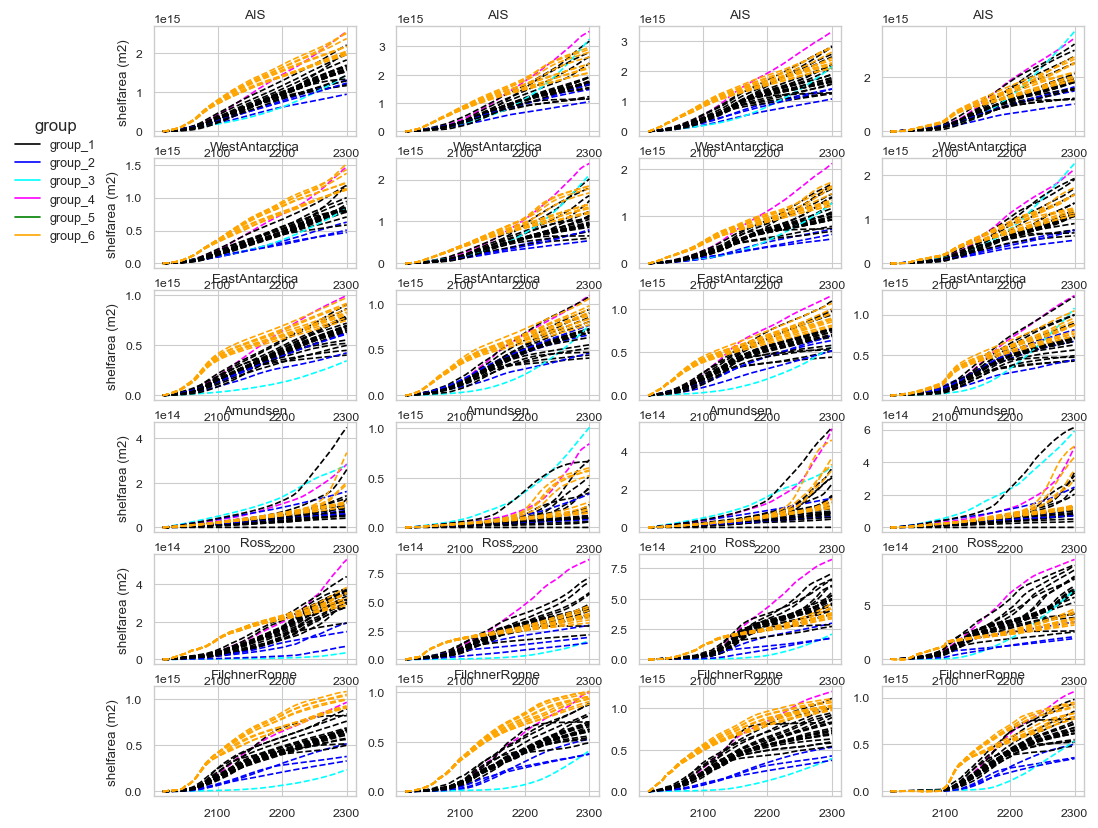

In [154]:

dic_colors_groupcat = {}
for i in range(6):
    key = 'group_'+str(i+1)
    dic_colors_groupcat[key]=cols_u[i]

#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_groupcat.items()]


f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = cols_u[groups_cat[k]]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' )
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   
f.legend(handles=legend_elements, title='group', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=9, title_fontsize=12,frameon=False)


### 

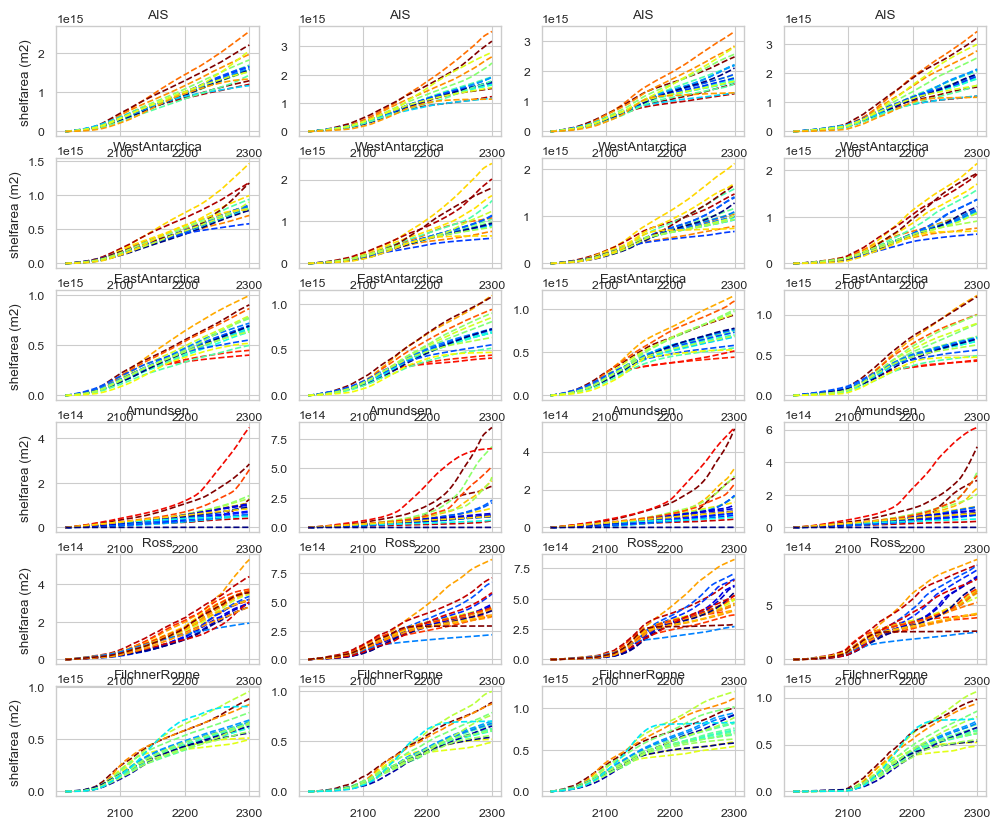

In [179]:
# No pico,no piop no lin
# qonlu quadratic
Models_1 = ['DC_ISSM',  'ILTS_SICOPOLIS', 'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
        'UCM_Yelmo',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO']
# Models_1 = ['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2' ,'VUW_PISM1_s3' ,'VUW_PISM1_s4'
#  'VUW_PISM2' ,'VUW_PISM2_s1' ,'VUW_PISM2_s2' ,'VUW_PISM2_s3' ,
# 'VUW_PISM2_s4']
# 'PIK_PISM','ULB_fETISh-KoriBU1','IGE_ElmerIce'
mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
#     ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]*(100 +df_iareafl2300_change_mean[f'{region}'].values[mask_special_model])
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
      
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   


In [177]:
df_info[df_info.Experiment == 'expAE02']



,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
21,21,IGE,Elmer/Ice,expAE02,CCSM4,IGE\_ElmerIce,IGE_ElmerIce,True,PICO,custom,1km,0.5km,No,No melt,Fix
26,26,ILTS,SICOPOLIS,expAE02,CCSM4,ILTS\_SICOPOLIS,ILTS_SICOPOLIS,True,Quad. Non-local,AntMean median,8km,8km,Floating condition,No melt,MH
51,51,LSCE,Grisli,expAE02,CCSM4,LSCE\_GRISLI,LSCE_GRISLI,True,Quad. Non-local,AntMean median,16km,16km,Floating condition,Sub-Grid,MH
56,56,LSCE,Grisli,expAE02,CCSM4,LSCE\_GRISLI2,LSCE_GRISLI2,False,Quad. Non-local,AntMean median,16km,16km,No,No melt,MH
61,61,NCAR,CISM,expAE02,CCSM4,NCAR\_CISM1,NCAR_CISM1,False,Quad. Non-local,AntMean median,4km,2km,Sub-Grid,Sub-Grid,RO
66,66,NCAR,CISM,expAE02,CCSM4,NCAR\_CISM2*,NCAR_CISM2,True,Quad. Local,AntMean median,4km,2km,Sub-Grid,Sub-Grid,RO
71,71,NORCE,CISM,expAE02,CCSM4,NORCE\_CISM2,NORCE_CISM2-MAR364-ERA-t1,False,Quad. Non-local Slope,AntMean median,4km,2km,Floating condition,Sub-Grid,RO
76,76,NORCE,CISM,expAE02,CCSM4,NORCE\_CISM3,NORCE_CISM3-MAR364-ERA-t1,False,Quad. Non-local Slope,AntMean median,8km,4km,Floating condition,Sub-Grid,RO
81,81,NORCE,CISM,expAE02,CCSM4,NORCE\_CISM3\_nonlocal*,NORCE_CISM3-MAR364-ERA-t1-nonlocal,True,Quad. Non-local,AntMean median,8km,4km,Floating condition,Sub-Grid,RO


### make groups

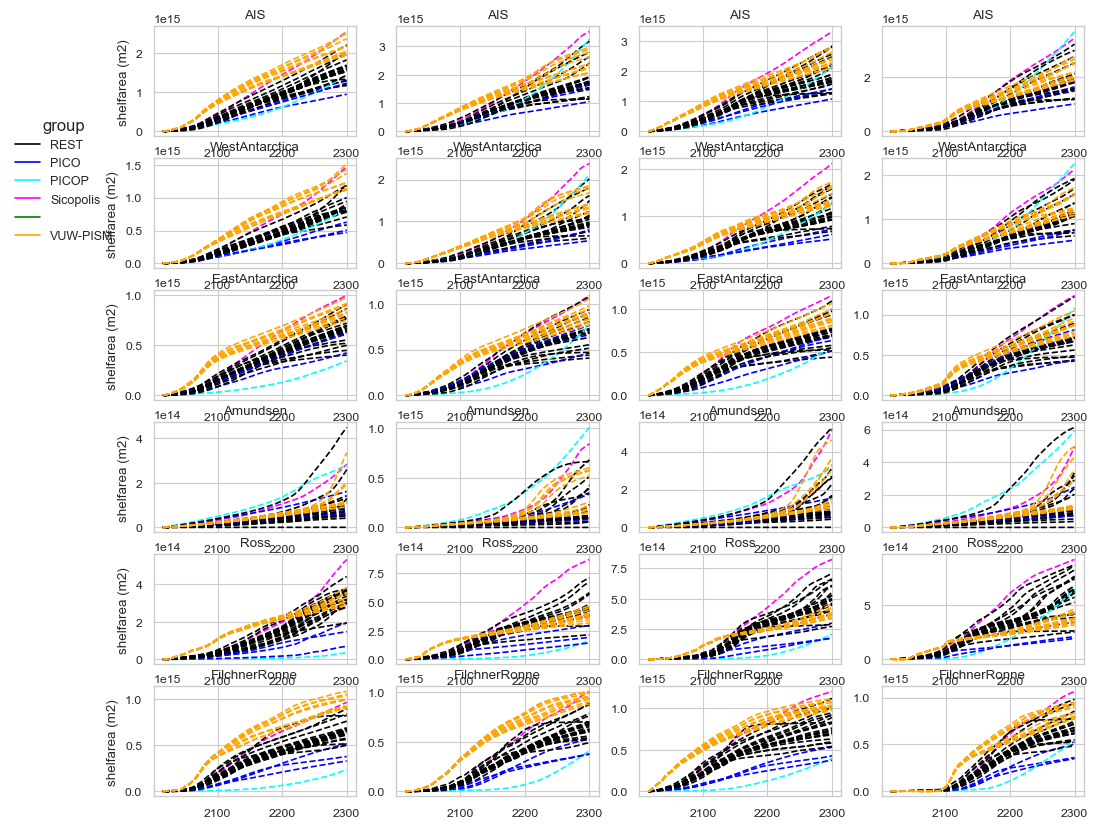

In [159]:

dic_colors_groupcat = {}
group_names = ['REST','PICO','PICOP','Sicopolis','','VUW-PISM']
dic_colors_groupcat = {}

for i in range(6):
    key = group_names[i]
    dic_colors_groupcat[key]=cols_u[i]

#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_groupcat.items()]


f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = cols_u[groups_cat[k]]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' )
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   
f.legend(handles=legend_elements, title='group', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=9, title_fontsize=12,frameon=False)


Div PICO
Models ['ULB_fETISh-KoriBU1']
Div Quad. Non-local
Models ['ULB_fETISh-KoriBU2']
Fix PICO
Models ['IGE_ElmerIce']
Fix PICOP
Models ['UCSD_ISSM']
Fix Quad. Local
Models ['UTAS_ElmerIce']
MH Quad. Non-local
Models ['DC_ISSM' 'ILTS_SICOPOLIS' 'LSCE_GRISLI2' 'LSCE_GRISLI' 'VUB_AISMPALEO']
RO Quad. Local
Models ['NCAR_CISM2' 'NORCE_CISM3-MAR364-ERA-t1-local'
 'NORCE_CISM4-MAR364-ERA-t1-local' 'NORCE_CISM5-MAR364-ERA-t1-local'
 'UNN_Ua']
RO Quad. Non-local
Models ['NCAR_CISM1' 'NORCE_CISM3-MAR364-ERA-t1-nonlocal'
 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' 'NORCE_CISM5-MAR364-ERA-t1-nonlocal']
RO Quad. Non-local Slope
Models ['NORCE_CISM2-MAR364-ERA-t1' 'NORCE_CISM3-MAR364-ERA-t1'
 'NORCE_CISM4-MAR364-ERA-t1' 'NORCE_CISM4-MAR364-JRA-t1'
 'NORCE_CISM5-MAR364-ERA-t1']
StR Lin
Models ['VUW_PISM1' 'VUW_PISM1_s1' 'VUW_PISM1_s2' 'VUW_PISM1_s3' 'VUW_PISM1_s4'
 'VUW_PISM2' 'VUW_PISM2_s1' 'VUW_PISM2_s2' 'VUW_PISM2_s3' 'VUW_PISM2_s4']
StR PICO
Models ['PIK_PISM']
VM Quad. Non-local
Models ['UCM_Yelm

[Text(0, 0, 'Div PICO'),
 Text(1, 0, 'Div Quad. Non-local'),
 Text(2, 0, 'Fix PICO'),
 Text(3, 0, 'Fix PICOP'),
 Text(4, 0, 'Fix Quad. Local'),
 Text(5, 0, 'MH Quad. Non-local'),
 Text(6, 0, 'RO Quad. Local'),
 Text(7, 0, 'RO Quad. Non-local'),
 Text(8, 0, 'RO Quad. Non-local Slope'),
 Text(9, 0, 'StR Lin'),
 Text(10, 0, 'StR PICO'),
 Text(11, 0, 'VM Quad. Non-local')]

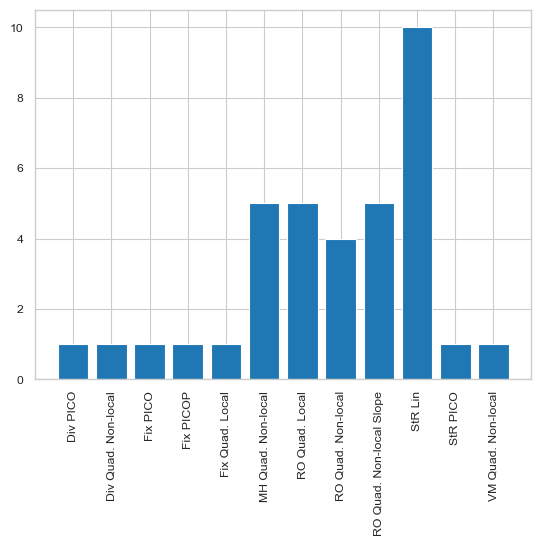

In [16]:
f,ax = plt.subplots(1,1)
counts = np.zeros(len(icefront_param_u))
for i,combi in enumerate(icefront_param_u):
    counts[i]=icefront_param_per_model[combi == icefront_param_per_model].size
    print(combi)
    print('Models',Models[combi == icefront_param_per_model])
    
ax.bar(np.arange(len(counts)),counts)
ax.set_xticks(np.arange(len(counts)))       
ax.set_xticklabels(icefront_param_u, rotation=90)

## let us look at the three combination that are used by different models
1. MH Quad. Non-local <br>
Models ['DC_ISSM' 'ILTS_SICOPOLIS' 'LSCE_GRISLI2' 'LSCE_GRISLI' 'VUB_AISMPALEO']<br>
2. RO Quad. Local<br>
Models ['NCAR_CISM2' 'NORCE_CISM3-MAR364-ERA-t1-local'
 'NORCE_CISM4-MAR364-ERA-t1-local' 'NORCE_CISM5-MAR364-ERA-t1-local'
 'UNN_Ua']<br>
3. RO Quad. Non-local<br>
Models ['NCAR_CISM1' 'NORCE_CISM3-MAR364-ERA-t1-nonlocal'
 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' 'NORCE_CISM5-MAR364-ERA-t1-nonlocal']<br>

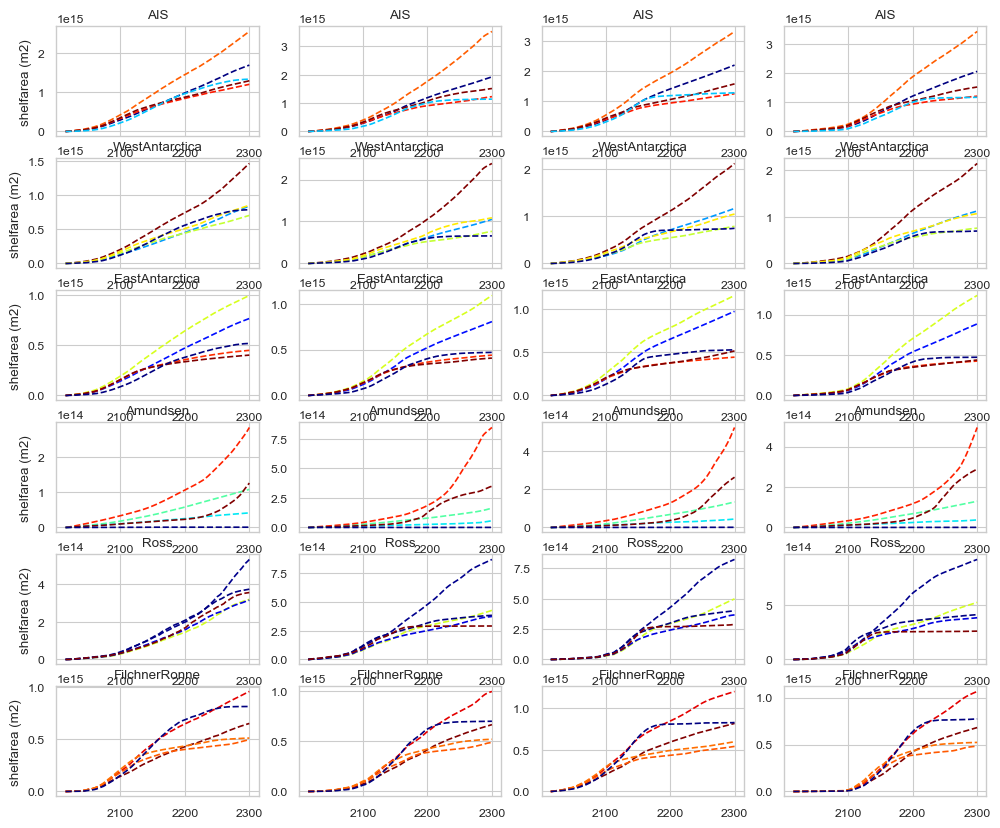

In [183]:

# No pico,no piop no lin
# qonlu quadratic
Models_1 = ['DC_ISSM' ,'ILTS_SICOPOLIS' ,'LSCE_GRISLI2' ,'LSCE_GRISLI' ,'VUB_AISMPALEO',\
           ]
# Models_1 = ['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2' ,'VUW_PISM1_s3' ,'VUW_PISM1_s4'
#  'VUW_PISM2' ,'VUW_PISM2_s1' ,'VUW_PISM2_s2' ,'VUW_PISM2_s3' ,
# 'VUW_PISM2_s4']
# 'PIK_PISM','ULB_fETISh-KoriBU1','IGE_ElmerIce'
mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]*(200 +df_iareafl2300_change_mean[f'{region}'].values[mask_special_model])
#     ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
      
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   


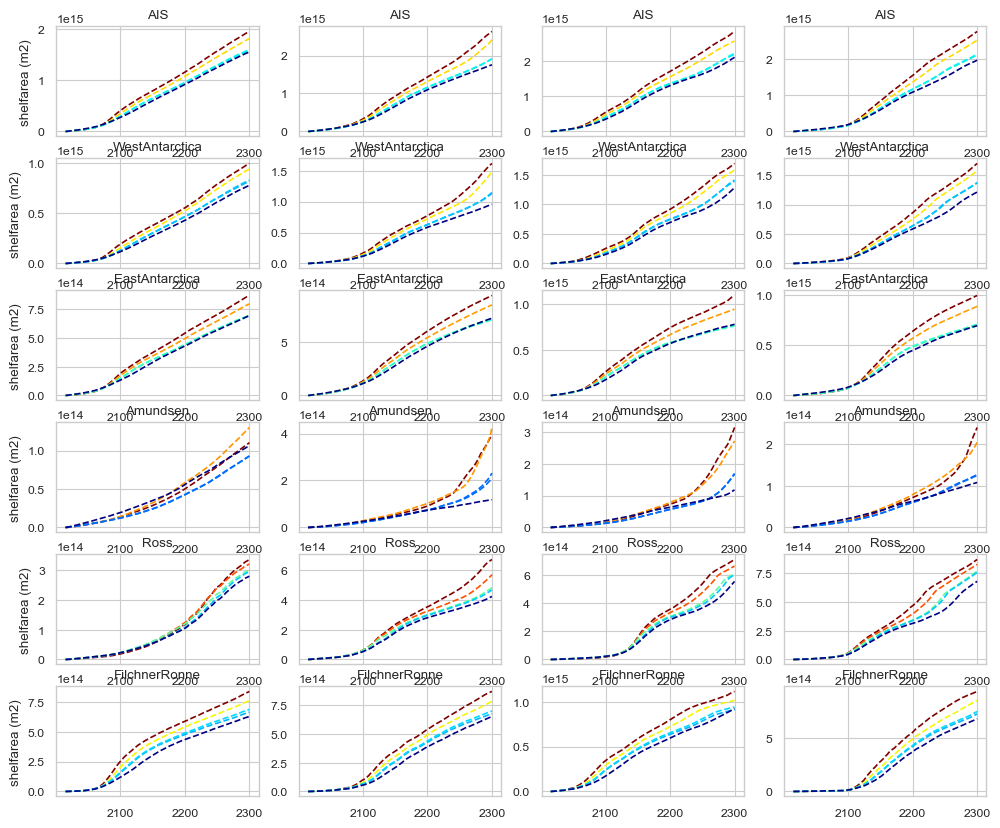

In [185]:

# No pico,no piop no lin
# qonlu quadratic
Models_1 = ['NORCE_CISM2-MAR364-ERA-t1' ,'NORCE_CISM3-MAR364-ERA-t1',
 'NORCE_CISM4-MAR364-ERA-t1' ,'NORCE_CISM4-MAR364-JRA-t1',
 'NORCE_CISM5-MAR364-ERA-t1']
# Models_1 = ['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2' ,'VUW_PISM1_s3' ,'VUW_PISM1_s4'
#  'VUW_PISM2' ,'VUW_PISM2_s1' ,'VUW_PISM2_s2' ,'VUW_PISM2_s3' ,
# 'VUW_PISM2_s4']
# 'PIK_PISM','ULB_fETISh-KoriBU1','IGE_ElmerIce'
mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
#     ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]*(200 +df_iareafl2300_change_mean[f'{region}'].values[mask_special_model])
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
      
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   


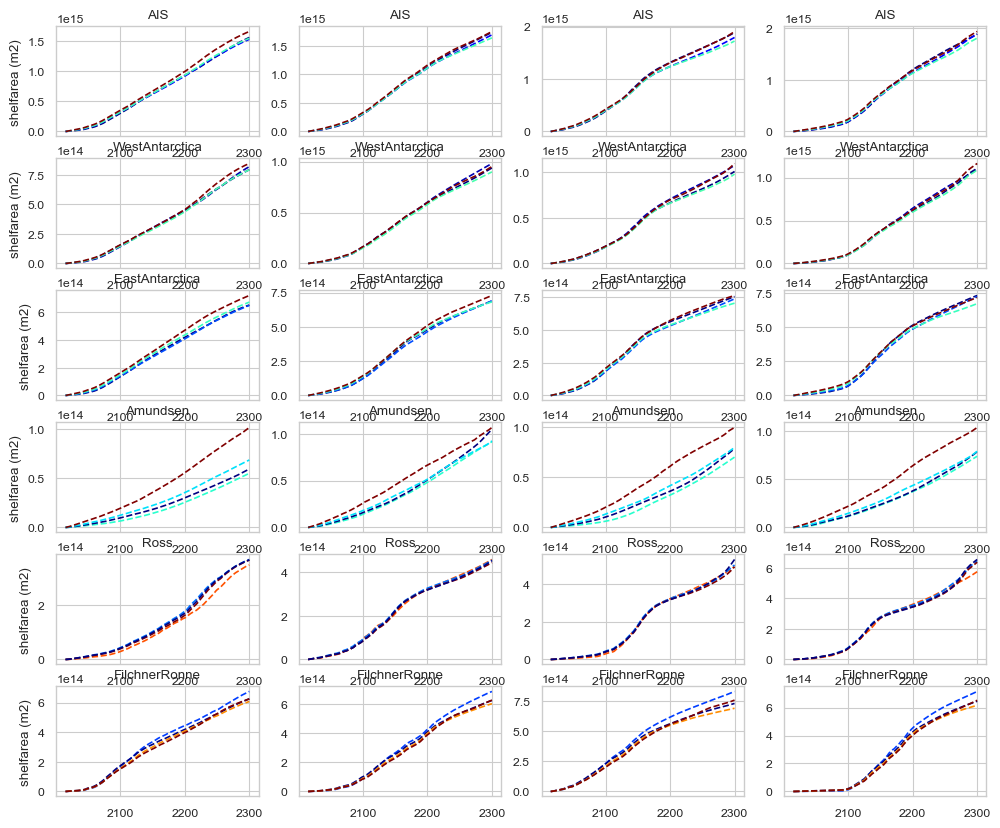

In [194]:

# No pico,no piop no lin
# qonlu quadratic
Models_1 = [ 'NCAR_CISM1', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal',
 'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal']
#,\
#             'DC_ISSM' ,'ILTS_SICOPOLIS' ,'LSCE_GRISLI2' ,'LSCE_GRISLI' ,'VUB_AISMPALEO']
# Models_1 = ['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2' ,'VUW_PISM1_s3' ,'VUW_PISM1_s4'
#  'VUW_PISM2' ,'VUW_PISM2_s1' ,'VUW_PISM2_s2' ,'VUW_PISM2_s3' ,
# 'VUW_PISM2_s4']
# 'PIK_PISM','ULB_fETISh-KoriBU1','IGE_ElmerIce'
mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]*1/2*(100* +df_iareafl2300_change_mean[f'{region}'].values[mask_special_model])
#     ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
      
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
#             ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   


In [202]:
df_info_exp = df_info[df_info.Experiment == 'expAE02']

In [219]:
df_info_exp 

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
21,21,IGE,Elmer/Ice,expAE02,CCSM4,IGE\_ElmerIce,IGE_ElmerIce,True,PICO,custom,1km,0.5km,No,No melt,Fix
26,26,ILTS,SICOPOLIS,expAE02,CCSM4,ILTS\_SICOPOLIS,ILTS_SICOPOLIS,True,Quad. Non-local,AntMean median,8km,8km,Floating condition,No melt,MH
51,51,LSCE,Grisli,expAE02,CCSM4,LSCE\_GRISLI,LSCE_GRISLI,True,Quad. Non-local,AntMean median,16km,16km,Floating condition,Sub-Grid,MH
56,56,LSCE,Grisli,expAE02,CCSM4,LSCE\_GRISLI2,LSCE_GRISLI2,False,Quad. Non-local,AntMean median,16km,16km,No,No melt,MH
61,61,NCAR,CISM,expAE02,CCSM4,NCAR\_CISM1,NCAR_CISM1,False,Quad. Non-local,AntMean median,4km,2km,Sub-Grid,Sub-Grid,RO
66,66,NCAR,CISM,expAE02,CCSM4,NCAR\_CISM2*,NCAR_CISM2,True,Quad. Local,AntMean median,4km,2km,Sub-Grid,Sub-Grid,RO
71,71,NORCE,CISM,expAE02,CCSM4,NORCE\_CISM2,NORCE_CISM2-MAR364-ERA-t1,False,Quad. Non-local Slope,AntMean median,4km,2km,Floating condition,Sub-Grid,RO
76,76,NORCE,CISM,expAE02,CCSM4,NORCE\_CISM3,NORCE_CISM3-MAR364-ERA-t1,False,Quad. Non-local Slope,AntMean median,8km,4km,Floating condition,Sub-Grid,RO
81,81,NORCE,CISM,expAE02,CCSM4,NORCE\_CISM3\_nonlocal*,NORCE_CISM3-MAR364-ERA-t1-nonlocal,True,Quad. Non-local,AntMean median,8km,4km,Floating condition,Sub-Grid,RO


In [218]:
r1 =df_info_exp[df_info_exp['Resolution']=='1km']
r1

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
21,21,IGE,Elmer/Ice,expAE02,CCSM4,IGE\_ElmerIce,IGE_ElmerIce,True,PICO,custom,1km,0.5km,No,No melt,Fix
136,136,UCSD,ISSM,expAE02,CCSM4,UCSD\_ISSM,UCSD_ISSM,True,PICOP,custom,1km,0.5km,Sub-Grid,No melt,Fix
151,151,UNN,Úa,expAE02,CCSM4,UNN\_'Ua,UNN_Ua,True,Quad. Local,AntMean median,1km,0.5km,No,No melt,RO
156,156,UTAS,Elmer/Ice,expAE02,CCSM4,UTAS\_ElmerIce,UTAS_ElmerIce,True,Quad. Local,AntMean median,1km,0.5km,Sub-Grid,No melt,Fix


In [222]:
param_u =['1km','4km','8km','16km','32km']
marker_u = ['^','v','*','s','P','p']
cols_u = ['black','steelblue','orange','crimson','green','cyan']
dic_marker = {}
dic_colors_param = {}

for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
    dic_colors_param[key]= cols_u[i]
markers = []
marker_nomodel=[]
colors_param = []
colors_param_nomodel = []

msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_info_exp['Resolution']:
    markers.append(dic_marker[key])
    colors_param.append(dic_colors_param[key])
for key in df_info_exp['Resolution'][msk]:
    marker_nomodel.append(dic_marker[key])
    colors_param_nomodel.append(dic_colors_param[key])
    

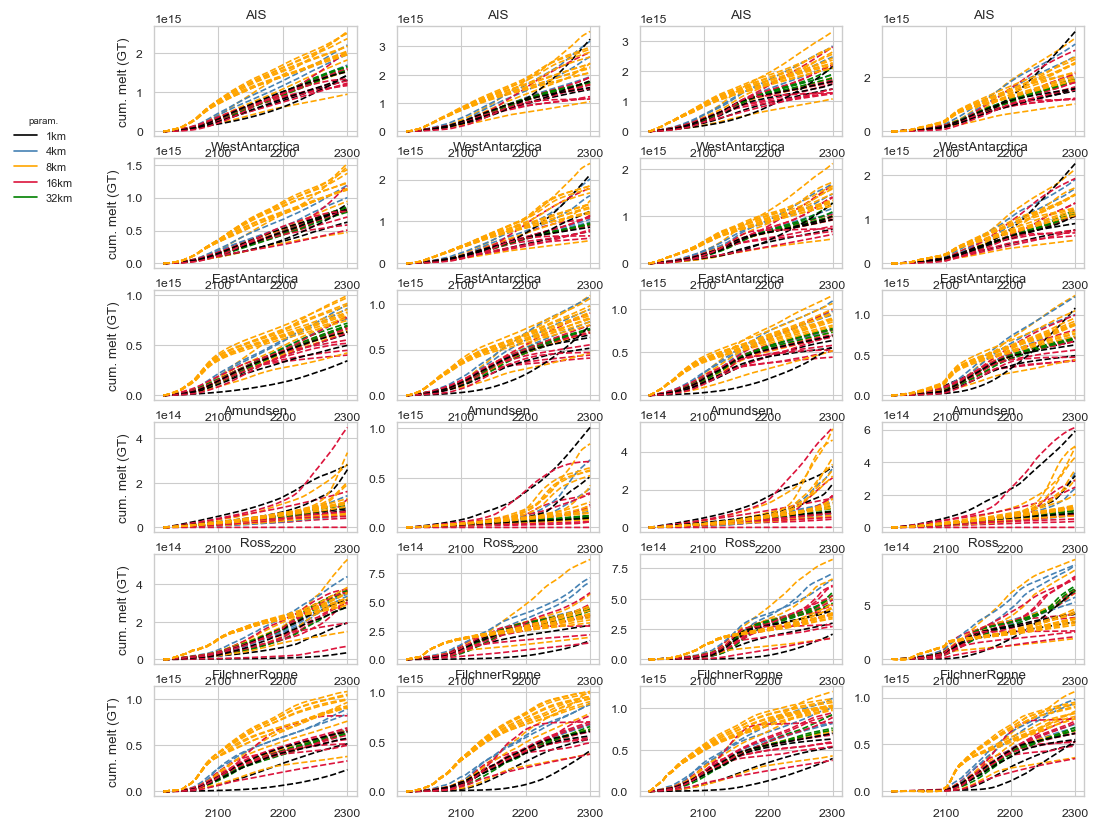

In [225]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_param.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = colors_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('cum. melt (GT)')
   
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=8, title_fontsize=7,frameon=False)


In [228]:
df_info['GL treatment'].unique()

array(['Sub-Grid', 'No', 'Floating condition', nan, 'Yes'], dtype=object)

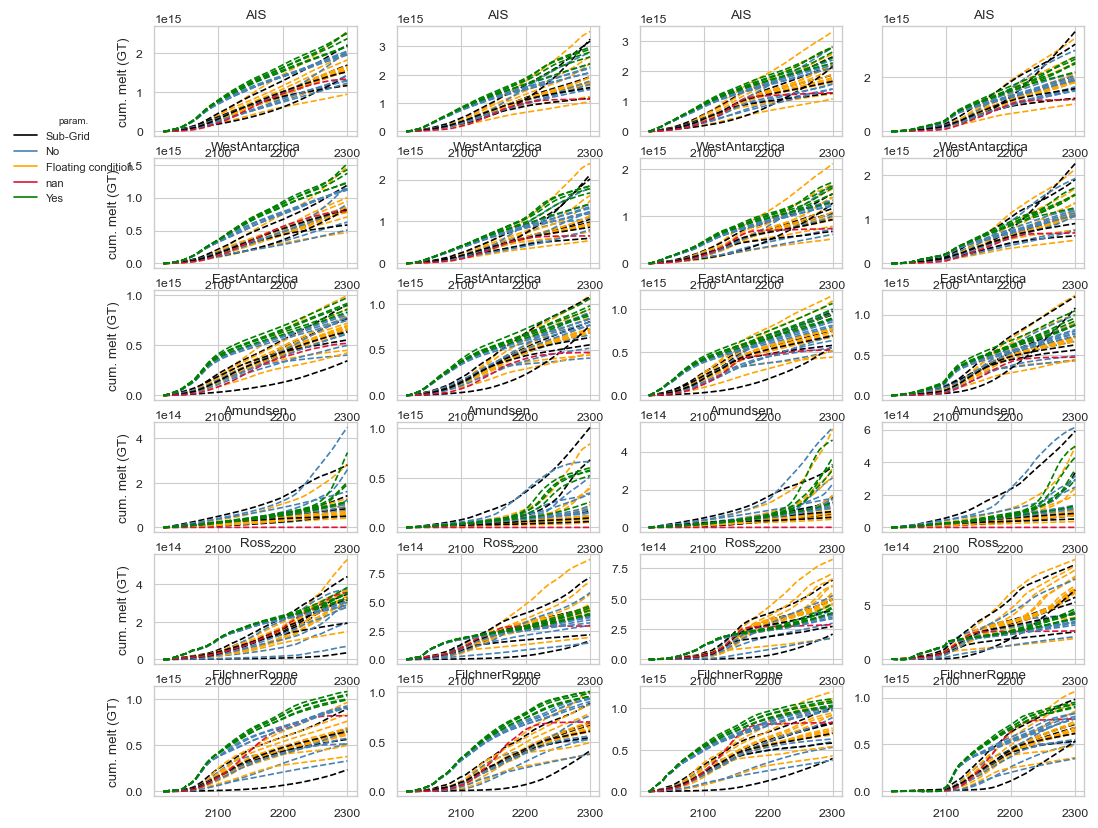

In [229]:
param_u =df_info['GL treatment'].unique()
marker_u = ['^','v','*','s','P','p']
cols_u = ['black','steelblue','orange','crimson','green','cyan']
dic_marker = {}
dic_colors_param = {}

for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
    dic_colors_param[key]= cols_u[i]
markers = []
marker_nomodel=[]
colors_param = []
colors_param_nomodel = []

msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_info_exp['GL treatment']:
    markers.append(dic_marker[key])
    colors_param.append(dic_colors_param[key])
for key in df_info_exp['GL treatment'][msk]:
    marker_nomodel.append(dic_marker[key])
    colors_param_nomodel.append(dic_colors_param[key])
    

#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_param.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0]
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'shelfmelt{key}'].values *factor
                y = y+melt
            y = y.cumsum()-y[0]
            col = colors_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('cum. melt (GT)')
   
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=8, title_fontsize=7,frameon=False)


In [ ]:
GL treatment